# 📊 Telecom Consumption Intelligence - Feature Documentation

## 🎯 Project Overview
Realistic telecom user behavior simulation mimicking data patterns from carriers like **MTN, Vodafone, and Verizon**. The project uses a **two-dataset architecture** separating raw behavioral data from derived usage metrics - an industry best practice.

---

## 📁 Dataset Architecture

### Why TWO Datasets?
In real telecom systems, we separate:
1. **Raw Activity Data** - What users are *doing*
2. **Aggregated Usage Data** - How much data they *consumed*

This separation enables:
- ✅ SQL analytics on behavior patterns
- ✅ ML model retraining with new features
- ✅ Data lineage tracking
- ✅ Scalable architecture

---

## 📊 Dataset 1: `user_activity` (Raw Behavioral Data)

### 🎯 Purpose
Captures **user behavior patterns** - what users actually do on the network. This is the **feature store** for ML models.

### 📋 Feature Dictionary

| Feature | Type | Description | Business Context |
|---------|------|-------------|------------------|
| `user_id` | String | Unique subscriber ID (e.g., `SUB1234567`) | Primary key, anonymized IMSI equivalent |
| `hours_streaming` | Float (0-8) | Hours spent on video/music apps | **Highest data consumer** - Netflix, YouTube, Spotify |
| `hours_social` | Float (0-6) | Hours on social platforms | Moderate consumption - Instagram, TikTok, Facebook |
| `hours_messaging` | Float (0-4) | Hours on messaging apps | **Lowest consumption** - WhatsApp, Telegram |
| `hours_gaming` | Float (0-6) | Hours mobile gaming | Variable usage - latency sensitive |
| `background_data_mb` | Float (5-200) | System data consumption | Always-on - updates, sync, location |
| `is_peak_hour_user` | Binary (0/1) | Measurement during 6-9 PM | Network congestion indicator |
| `is_weekend` | Binary (0/1) | Weekend vs weekday | Usage pattern shift indicator |
| `age_group` | Categorical | User age bracket | Demographic segmentation |
| `plan_type` | Categorical | Subscription tier | Revenue segmentation, ARPU |
| `device_type` | Categorical | Device category | Hardware capability indicator |
| `network_type` | Categorical | Network technology (3G/4G/5G) | Infrastructure capability |
| `measurement_date` | Date | Timestamp of observation | Trend analysis |


## 💾 Dataset 2: `user_data_usage` (Derived Target Data)

### 🎯 Purpose
Contains **calculated data consumption** - this is what ML models **predict**. This dataset serves as the **target variable store** for supervised learning tasks.

**Key Concept:** While `user_activity` captures *behavior*, this dataset captures *outcomes* - the actual data consumed.

---

### 📋 Feature Dictionary

| Feature | Type | Description | Calculation |
|---------|------|-------------|-------------|
| `user_id` | String | Unique subscriber identifier | Links to `user_activity` table |
| `total_data_mb` | Float | **Primary ML Target** - Total daily data consumption in megabytes | Sum of all data sources + random variation |
| `total_data_gb` | Float | Total daily data consumption in gigabytes (standard billing unit) | `total_data_mb / 1024` |
| `streaming_data_mb` | Float | Data consumed from video/music streaming apps | `hours_streaming × streaming_rate` |
| `social_data_mb` | Float | Data consumed from social media platforms | `hours_social × social_rate` |
| `messaging_data_mb` | Float | Data consumed from messaging applications | `hours_messaging × messaging_rate` |
| `gaming_data_mb` | Float | Data consumed from mobile gaming | `hours_gaming × gaming_rate` |
| `data_usage_category` | Categorical | User classification based on consumption tier | Binned `total_data_gb` values |

---

### 📊 Data Consumption Rates (MB/hour)

| Activity | 3G Network | 4G Network | 5G Network | Business Notes |
|----------|------------|------------|------------|----------------|
| **Streaming** | 300 - 500 | 700 - 1,200 | 1,500 - 2,500 | Quality auto-adjusts to network speed |
| **Social Media** | 80 - 150 | 150 - 300 | 250 - 400 | Video autoplay significantly impacts usage |
| **Messaging** | 5 - 20 | 5 - 20 | 5 - 20 | Minimal network impact regardless of technology |
| **Gaming** | 40 - 200 | 40 - 200 | 40 - 200 | Varies by game type, not network speed |

> **Industry Insight:** Streaming dominates network traffic (~70-80% of total data), making it the primary driver of infrastructure costs.

---

### 🎯 Target Variable Details

#### Primary Target: `total_data_gb`
- **Use Case:** Regression models predicting data consumption



In [41]:
# IMPORT NECESSARY LIBRARIES
import os
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [42]:
# ======================================
# PANDAS & SEABORN CONFIGURATION
# ======================================

# ----- PANDAS DISPLAY SETTINGS -----
# Display all columns and rows without truncation
pd.set_option('display.max_columns', None)  
pd.set_option('display.max_rows', 100)  # Limit rows to avoid excessive output
pd.set_option('display.width', 1000)    # Adjust display width for better readability
pd.set_option('display.colheader_justify', 'center')  # Center-align headers

# Floating-point precision (2 decimal places)
pd.options.display.float_format = '{:,.2f}'.format  # Adds thousand separators

# Improve performance with larger datasets
pd.set_option('compute.use_numexpr', True)  # Faster numerical operations
pd.set_option('mode.chained_assignment', 'warn')  # Warn on chained assignments

# ----- SEABORN & MATPLOTLIB STYLING -----
# Set a modern and clean style
sns.set_theme(
    style="whitegrid",  # Background grid for better readability
    context="notebook",  # Optimize for notebook display
    palette="deep",      # Aesthetic color palette
    font="sans-serif",   # Clean font
    font_scale=1.1,      # Slightly larger font size
    rc={
        'figure.figsize': (10, 6),  # Default figure size
        'axes.titlesize': 16,       # Title font size
        'axes.labelsize': 14,        # Axis label size
        'xtick.labelsize': 12,      # X-tick label size
        'ytick.labelsize': 12,       # Y-tick label size
        'grid.alpha': 0.3,          # Grid transparency
        'grid.color': "0.9",        # Light grid color
    }
)

# Improve matplotlib defaults
plt.rcParams['figure.dpi'] = 100      # Higher resolution for figures
plt.rcParams['savefig.dpi'] = 300     # High DPI for saved figures
plt.rcParams['lines.linewidth'] = 2   # Thicker plot lines
plt.rcParams['axes.edgecolor'] = '0.15'  # Softer axis edge color

# Disable scientific notation for small numbers
pd.options.display.float_format = '{:,.2f}'.format
pd.set_option('display.float_format', lambda x: '%.2f' % x)
np.set_printoptions(suppress=True)   # Suppress scientific notation in NumPy




# Suppress unnecessary warnings (optional)
import warnings

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=pd.errors.PerformanceWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')

# Keep important warnings
warnings.filterwarnings('always', category=DeprecationWarning)

In [ ]:

def load_and_inspect_data(data_folder, file_name, show_info=True, show_missing=True, show_duplucates=True):

    try:
        # Read the CSV file
        df = pd.read_csv(f"{data_folder}\\{file_name}")
        print(f"Shape: {df.shape} (Rows: {df.shape[0]}, Columns: {df.shape[1]})")
        print("Data loaded successfully.")
        display(df.head())
        
        # Display basic info about the dataframe
        if show_info:
            print('\nDataFrame Info:')
            display(df.info())
        
        # Missing values summary
        if show_missing:
            print("\nMissing Values:")
            missing = df.isna().sum().to_frame(name='Missing Values')
            missing['missing %'] = (missing['Missing Values'] / len(df)) * 100
            display(missing.sort_values(by='missing %', ascending=False))

        #Duplucate values summary
        if show_duplucates:
            print("\nDuplicate Values:")
            display(df.duplicated().sum().to_frame(name='Duplicate Values'))   
        
        return df
        
    except FileNotFoundError:
        print("CSV file not found. Please check the file path.")
        return None
    except Exception as e:
        print(f"Error reading CSV file: {e}")
        return None

# Usage example:
data_folder = r"G:\Study\DATA SCINCE\PROJECTS\POTFOLIO\telecom-consumption-intelligence\data\processed"
file_name = "user_activity_data_daily.csv"
df = load_and_inspect_data(data_folder, file_name)

Shape: (10006, 18) (Rows: 10006, Columns: 18)
Data loaded successfully.


,user_id,measurement_date,hours_streaming,hours_social,hours_messaging,hours_gaming,streaming_data_mb,social_data_mb,messaging_data_mb,gaming_data_mb,total_data_mb,is_peak_hour_user,is_weekend,age_group,plan_type,device_type,network_type,data_usage_category
0,SUB7423388,2026-04-07,0.33,0.66,0.87,0.37,542.92,133.07,13.32,60.29,756.41,0,1,18-24,Prepaid_Monthly,Mid_Range,4G+,Light
1,SUB7550634,2026-04-06,1.07,3.03,0.46,0.04,1214.57,814.33,8.67,3.00,2292.13,0,0,45-54,Postpaid_Premium,5G_Device,4G,Moderate
2,SUB5304572,2026-03-20,0.54,0.45,0.71,1.25,814.07,102.50,11.07,149.01,1124.30,1,0,25-34,Postpaid_Unlimited,Mid_Range,4G,Light
3,SUB3234489,2026-04-14,3.38,1.92,0.00,1.18,12057.73,624.75,0.00,132.93,12649.53,1,0,45-54,Postpaid_Unlimited,5G_Device,5G,Power_User
4,SUB8204212,2026-03-31,0.25,0.38,0.13,0.47,178.69,92.37,0.86,71.80,500.87,0,1,25-34,Prepaid_Daily,Premium_Smartphone,4G,Very_Light



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10006 entries, 0 to 10005
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              10006 non-null  object 
 1   measurement_date     10006 non-null  object 
 2   hours_streaming      10006 non-null  float64
 3   hours_social         10006 non-null  float64
 4   hours_messaging      10006 non-null  float64
 5   hours_gaming         10006 non-null  float64
 6   streaming_data_mb    10006 non-null  float64
 7   social_data_mb       10006 non-null  float64
 8   messaging_data_mb    10006 non-null  float64
 9   gaming_data_mb       10006 non-null  float64
 10  total_data_mb        10006 non-null  float64
 11  is_peak_hour_user    10006 non-null  int64  
 12  is_weekend           10006 non-null  int64  
 13  age_group            10006 non-null  object 
 14  plan_type            10006 non-null  object 
 15  device_type        

None


Missing Values:


,Missing Values,missing %
user_id,0,0.00
measurement_date,0,0.00
hours_streaming,0,0.00
hours_social,0,0.00
hours_messaging,0,0.00
hours_gaming,0,0.00
streaming_data_mb,0,0.00
social_data_mb,0,0.00
messaging_data_mb,0,0.00
gaming_data_mb,0,0.00



Duplicate Values:
Error reading CSV file: 'numpy.int64' object has no attribute 'to_frame'


In [46]:
# LOAD DATA

data_folder = r"G:\Study\DATA SCINCE\PROJECTS\POTFOLIO\telecom-consumption-intelligence\data\processed"
file_name = "user_activity_data_daily.csv"

try:
    # Read the CSV file
    df = pd.read_csv(f"{data_folder}\\{file_name}")
    print(f"Shape: {df.shape} (Rows: {df.shape[0]}, Columns: {df.shape[1]})")
    print("Data loaded successfully.")
    display(df.head())

    # Display basic info about the dataframe
    print('\n DataFrame Info:')
    display(df.info())

    # missing values summary
    print("\n Missing Values:")
    missing = df.isna().sum().to_frame(name='Missing Values')
    missing['missing %'] = (missing['Missing Values'] / len(df))*100
    display(missing.sort_values(by='missing %', ascending=False))

except FileNotFoundError:
    print("Csv file not found. Please check the file path.")    
except Exception as e:
    print(f"Error reading Csv file: {e}")

Shape: (10006, 18) (Rows: 10006, Columns: 18)
Data loaded successfully.


,user_id,measurement_date,hours_streaming,hours_social,hours_messaging,hours_gaming,streaming_data_mb,social_data_mb,messaging_data_mb,gaming_data_mb,total_data_mb,is_peak_hour_user,is_weekend,age_group,plan_type,device_type,network_type,data_usage_category
0,SUB7423388,2026-04-07,0.33,0.66,0.87,0.37,542.92,133.07,13.32,60.29,756.41,0,1,18-24,Prepaid_Monthly,Mid_Range,4G+,Light
1,SUB7550634,2026-04-06,1.07,3.03,0.46,0.04,1214.57,814.33,8.67,3.00,2292.13,0,0,45-54,Postpaid_Premium,5G_Device,4G,Moderate
2,SUB5304572,2026-03-20,0.54,0.45,0.71,1.25,814.07,102.50,11.07,149.01,1124.30,1,0,25-34,Postpaid_Unlimited,Mid_Range,4G,Light
3,SUB3234489,2026-04-14,3.38,1.92,0.00,1.18,12057.73,624.75,0.00,132.93,12649.53,1,0,45-54,Postpaid_Unlimited,5G_Device,5G,Power_User
4,SUB8204212,2026-03-31,0.25,0.38,0.13,0.47,178.69,92.37,0.86,71.80,500.87,0,1,25-34,Prepaid_Daily,Premium_Smartphone,4G,Very_Light



 DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10006 entries, 0 to 10005
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              10006 non-null  object 
 1   measurement_date     10006 non-null  object 
 2   hours_streaming      10006 non-null  float64
 3   hours_social         10006 non-null  float64
 4   hours_messaging      10006 non-null  float64
 5   hours_gaming         10006 non-null  float64
 6   streaming_data_mb    10006 non-null  float64
 7   social_data_mb       10006 non-null  float64
 8   messaging_data_mb    10006 non-null  float64
 9   gaming_data_mb       10006 non-null  float64
 10  total_data_mb        10006 non-null  float64
 11  is_peak_hour_user    10006 non-null  int64  
 12  is_weekend           10006 non-null  int64  
 13  age_group            10006 non-null  object 
 14  plan_type            10006 non-null  object 
 15  device_type       

None


 Missing Values:


,Missing Values,missing %
user_id,0,0.00
measurement_date,0,0.00
hours_streaming,0,0.00
hours_social,0,0.00
hours_messaging,0,0.00
hours_gaming,0,0.00
streaming_data_mb,0,0.00
social_data_mb,0,0.00
messaging_data_mb,0,0.00
gaming_data_mb,0,0.00


In [53]:
def comprehensive_describe(df):
    """Generate comprehensive descriptive statistics"""
    if df is None:
        print("Error: DataFrame is None.")
        return
    
    # Basic info
    print("="*60)
    print("DATAFRAME OVERVIEW")
    print("="*60)
    print(f"Data Types:\n{df.dtypes.value_counts()}")
    
    # Numeric columns
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
    if len(numeric_cols) > 0:
        print("\n" + "="*60)
        print(f"NUMERIC COLUMNS ({len(numeric_cols)}):")
        print("="*60)
        display(df[numeric_cols].describe().T)
    
    # Categorical/Text columns
    cat_cols = df.select_dtypes(include=['object', 'category']).columns
    if len(cat_cols) > 0:
        print("\n" + "="*60)
        print(f"CATEGORICAL/TEXT COLUMNS ({len(cat_cols)}):")
        print("="*60)
        display(df[cat_cols].describe(include='O').T)
        
        # Show unique value counts for categorical columns
        print("\nUnique Values per Categorical Column:")
        for col in cat_cols:
            print(f"  {col}: {df[col].nunique()} unique values")

# Usage
comprehensive_describe(df)

DATAFRAME OVERVIEW
Data Types:
float64    9
object     7
int64      2
Name: count, dtype: int64

NUMERIC COLUMNS (11):


,count,mean,std,min,25%,50%,75%,max
hours_streaming,10006.00,1.70,1.84,0.00,0.44,1.05,2.23,8.00
hours_social,10006.00,1.65,1.55,0.00,0.52,1.13,2.26,6.00
hours_messaging,10006.00,0.58,0.76,0.00,0.11,0.30,0.73,4.00
hours_gaming,10006.00,0.59,0.89,0.00,0.09,0.27,0.71,6.00
streaming_data_mb,10006.00,2738.07,4000.00,0.00,458.52,1261.22,3234.66,34221.24
social_data_mb,10006.00,417.70,447.73,0.00,109.49,251.69,555.55,2395.45
messaging_data_mb,10006.00,7.31,10.49,0.00,1.21,3.51,8.73,79.83
gaming_data_mb,10006.00,70.96,118.77,0.00,9.07,29.67,80.01,1187.91
total_data_mb,10006.00,3311.64,4263.09,11.50,800.75,1784.66,3958.67,37874.04
is_peak_hour_user,10006.00,0.29,0.46,0.00,0.00,0.00,1.00,1.00



CATEGORICAL/TEXT COLUMNS (7):


,count,unique,top,freq
user_id,10006,9997,SUB8156406,4
measurement_date,10006,30,2026-04-02,369
age_group,10006,5,25-34,3049
plan_type,10006,5,Prepaid_Monthly,2548
device_type,10006,5,Mid_Range,3517
network_type,10006,4,4G,4480
data_usage_category,10006,5,Light,3977



Unique Values per Categorical Column:
  user_id: 9997 unique values
  measurement_date: 30 unique values
  age_group: 5 unique values
  plan_type: 5 unique values
  device_type: 5 unique values
  network_type: 4 unique values
  data_usage_category: 5 unique values


In [51]:
df['data_usage_category'].value_counts()

data_usage_category
Light         3977
Moderate      2686
Very_Light    1469
Heavy         1205
Power_User     669
Name: count, dtype: int64

<Axes: xlabel='total_data_mb', ylabel='Count'>

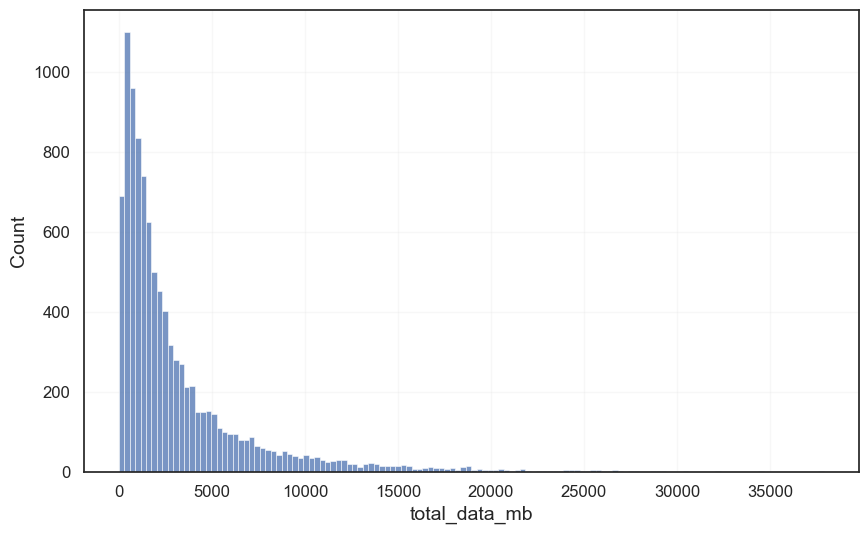

In [54]:
sns.histplot(df['total_data_mb'], kde=False)